# Assignment

## Instructions

In this assignment, you will apply time series forecasting techniques to analyze and predict future values. You will work with the "Global Temperature Time Series" dataset, which contains monthly temperature anomalies from 1880 to present day.

### Task: Global Temperature Forecasting

Your task is to analyze the global temperature time series and build forecasting models to predict future temperature trends. Follow these steps:

1. **Data Exploration**

   - Load and prepare the dataset
   - Visualize the time series data
   - Check for trends, seasonality, and cycles
   - Create seasonal plots and subseries plots
   - Analyze autocorrelation using ACF plots

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.utils.plotting import plot_series

# Load the dataset (NASA GISTEMP Global Temperature Anomaly)
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# Data preparation
def prepare_nasa_data(url):
    # Read the data, skipping the header explanation
    df = pd.read_csv(url, skiprows=1)

    # Remove the unnecessary columns
    df = df.iloc[:, :13]

    # Rename columns
    df.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Convert from wide to long format
    df_long = df.melt(id_vars=['Year'],
                       var_name='Month',
                       value_name='Temperature_Anomaly')

    # Filter out missing or invalid data
    df_long = df_long[df_long['Temperature_Anomaly'] != '***']
    df_long['Temperature_Anomaly'] = df_long['Temperature_Anomaly'].astype(float)

    # Create a proper date index
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Month'], format='%Y-%b')

    # Sort by date
    df_long = df_long.sort_values('Date')

    # Create a time series
    ts_data = df_long.set_index('Date')['Temperature_Anomaly']

    return ts_data

# Prepare the time series data
ts_data = prepare_nasa_data(url)

# Now you have a time series object 'ts_data' to work with
print(f"Time series data from {ts_data.index.min()} to {ts_data.index.max()}")
print(f"Total number of observations: {len(ts_data)}")

Time series data from 1880-01-01 00:00:00 to 2026-06-01 00:00:00
Total number of observations: 1758


In [2]:
type(ts_data)

pandas.core.series.Series

In [3]:
ts_data

Date
1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.10
1880-04-01   -0.17
1880-05-01   -0.11
              ... 
2026-02-01    1.25
2026-03-01    1.32
2026-04-01    1.17
2026-05-01    1.13
2026-06-01    1.18
Name: Temperature_Anomaly, Length: 1758, dtype: float64

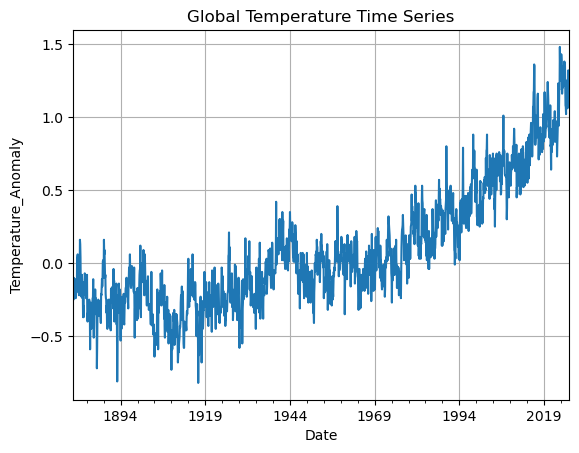

In [4]:
# Visualiza the time series data. 
ts_data.plot()
plt.title('Global Temperature Time Series')
plt.xlabel('Date')
plt.ylabel(ts_data.name)
plt.grid(True)
plt.show()

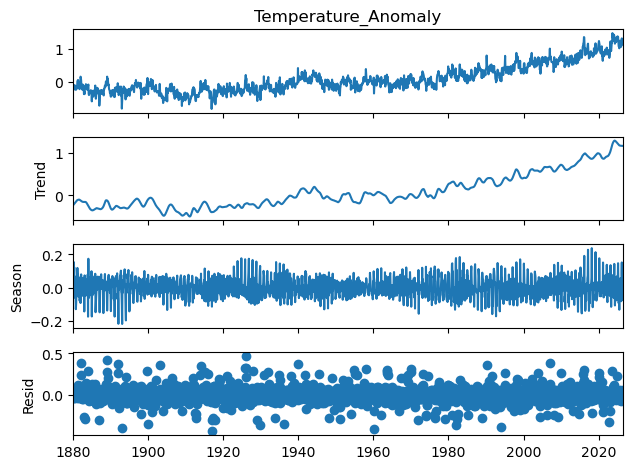

In [5]:
# Check for trends, seasonality, and cycles. 
from statsmodels.tsa.seasonal import STL

# Check for trends, seasonality, and cycles. Perform STL decomposition
stl = STL(ts_data, period=12, robust=True)
stl_result = stl.fit()

# Plot the decomposed components
fig = stl_result.plot()
plt.show()

In [6]:
# ADF TEST — trend / stationarity check
from statsmodels.tsa.stattools import adfuller
from scipy.signal import periodogram

def report_adf(series, label):
    stat, pval, lags_used, nobs, crit, icbest = adfuller(series.dropna(), autolag="AIC")
    print(f"\n--- ADF test: {label} ---")
    print(f"Test statistic: {stat:.4f}")
    print(f"p-value:        {pval:.4f}")
    print(f"Lags used:      {lags_used}")
    for k, v in crit.items():
        print(f"Critical value ({k}): {v:.4f}")
    verdict = "STATIONARY (reject H0)" if pval < 0.05 else "NON-STATIONARY (fail to reject H0)"
    print(f"Verdict: {verdict}")
    return stat, pval
 
adf_raw = report_adf(ts_data, "Raw monthly anomaly")
adf_diff = report_adf(ts_data.diff(), "First-differenced series")
adf_detrend = report_adf(ts_data - stl_result.trend, "Series minus STL trend")


--- ADF test: Raw monthly anomaly ---
Test statistic: 0.0349
p-value:        0.9613
Lags used:      24
Critical value (1%): -3.4341
Critical value (5%): -2.8632
Critical value (10%): -2.5677
Verdict: NON-STATIONARY (fail to reject H0)

--- ADF test: First-differenced series ---
Test statistic: -12.3454
p-value:        0.0000
Lags used:      23
Critical value (1%): -3.4341
Critical value (5%): -2.8632
Critical value (10%): -2.5677
Verdict: STATIONARY (reject H0)

--- ADF test: Series minus STL trend ---
Test statistic: -9.8685
p-value:        0.0000
Lags used:      25
Critical value (1%): -3.4341
Critical value (5%): -2.8632
Critical value (10%): -2.5677
Verdict: STATIONARY (reject H0)


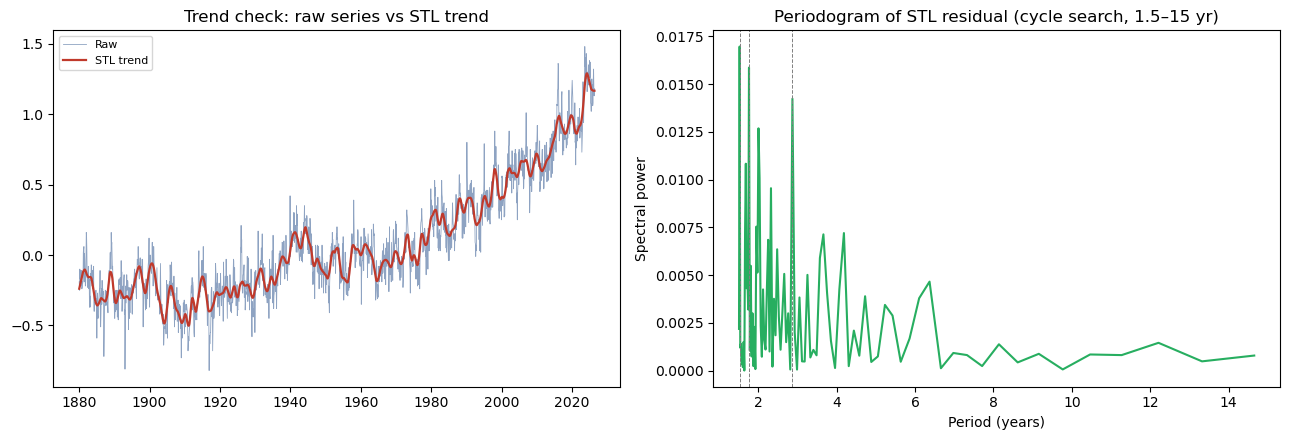


Top candidate cycle periods (years): [2.872549019607843, 1.7650602409638554, 1.5260416666666667]


In [7]:
#  PERIODOGRAM — cycle detection on the STL residual
#    (trend and seasonal removed, so any remaining peak is a non-seasonal cycle, e.g. ENSO-like behavior)

resid = stl_result.resid.dropna()
freqs, power = periodogram(resid, fs=12)  # fs=12 -> frequency in cycles/year
periods_years = np.divide(1, freqs, out=np.full_like(freqs, np.inf), where=freqs != 0)
 
# restrict to periods between 1.5 and 15 years for readability
mask = (periods_years >= 1.5) & (periods_years <= 15)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ts_data.index, ts_data, color="#8ea3c2", lw=0.6, label="Raw")
axes[0].plot(ts_data.index, stl_result.trend, color="#c0392b", lw=1.6, label="STL trend")
axes[0].set_title("Trend check: raw series vs STL trend")
axes[0].legend(fontsize=8)
 
axes[1].plot(periods_years[mask], power[mask], color="#27ae60")
top_idx = np.argsort(power[mask])[-3:]
top_periods = periods_years[mask][top_idx]
for p in top_periods:
    axes[1].axvline(p, color="gray", linestyle="--", linewidth=0.7)
axes[1].set_xlabel("Period (years)")
axes[1].set_ylabel("Spectral power")
axes[1].set_title("Periodogram of STL residual (cycle search, 1.5–15 yr)")
fig.tight_layout()
plt.show()
 
print("\nTop candidate cycle periods (years):", sorted(top_periods, reverse=True))

Trend: strong, long-term upward movement in the data, with p=0,96 indicating a statistically confirmed trend.
Seasonality: technically present but negligible.
Cycles: a real ~2-3 year quasi-periodic component in the residual, likely ENSO-driven, but it's much smaller than the trend. 

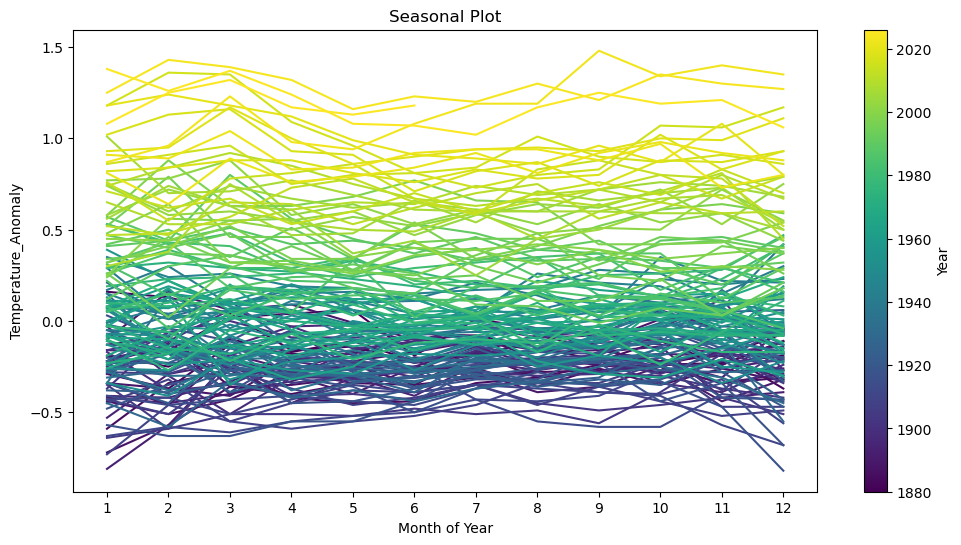

In [8]:
# Create seasonal plot.
import matplotlib.colors as mcolors

years = ts_data.index.year.unique()

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=years.min(), vmax=years.max())

fig, ax = plt.subplots(figsize=(12, 6))

for year in years:
    mask = ts_data.index.year == year
    ax.plot(ts_data[mask].index.month, ts_data[mask], color=cmap(norm(year)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Year')

ax.set_title('Seasonal Plot')
ax.set_xlabel('Month of Year')
ax.set_xticks(range(1, 13))
ax.set_ylabel(ts_data.name)
plt.show()

In [9]:
#Create subseries plots.
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_expanded = pd.DataFrame({
    'period': ts_data.index,
    'value': ts_data.values,
    'month': pd.Categorical(ts_data.index.strftime('%b'), categories=month_order, ordered=True),
    'year': ts_data.index.year
})
df_expanded

,period,value,month,year
0,1880-01-01,-0.19,Jan,1880
1,1880-02-01,-0.25,Feb,1880
2,1880-03-01,-0.10,Mar,1880
3,1880-04-01,-0.17,Apr,1880
4,1880-05-01,-0.11,May,1880
...,...,...,...,...
1753,2026-02-01,1.25,Feb,2026
1754,2026-03-01,1.32,Mar,2026
1755,2026-04-01,1.17,Apr,2026
1756,2026-05-01,1.13,May,2026


/home/liuyx/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/liuyx/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/liuyx/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liuyx/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

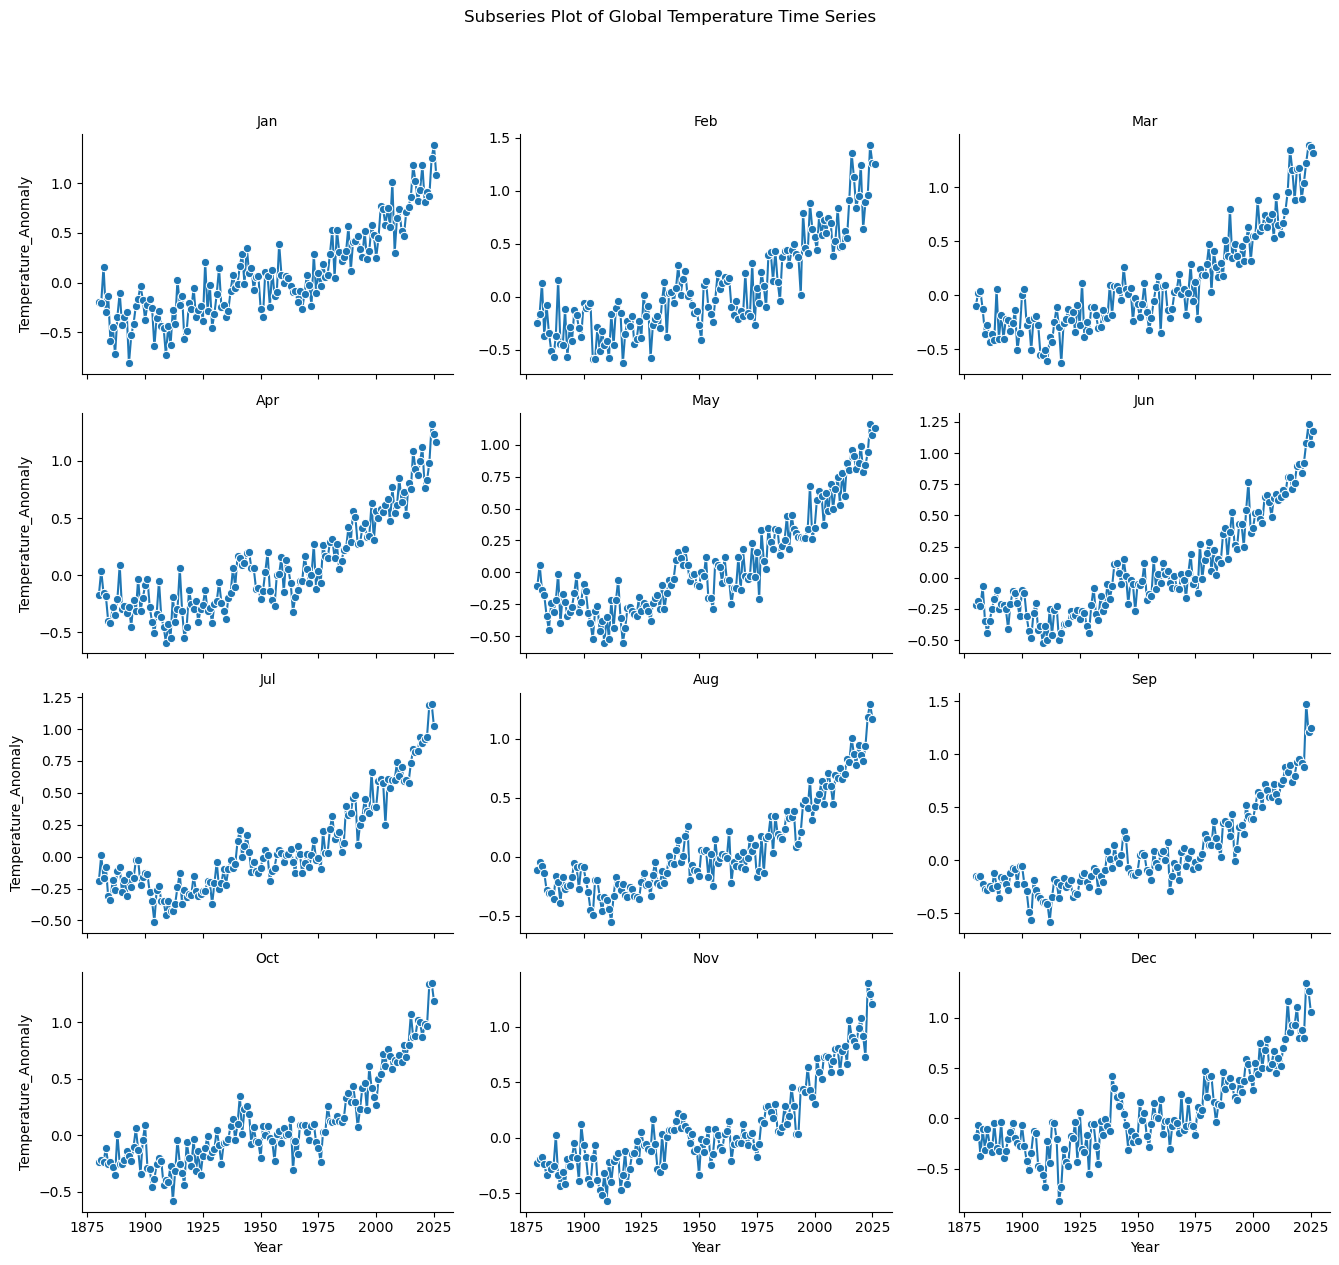

In [10]:
g = sns.FacetGrid(df_expanded, col="month", col_wrap=3, height=3, aspect=1.5, sharey=False)
g.map(sns.lineplot, "year", "value", marker='o')
g.set_axis_labels('Year', 'Temperature_Anomaly')
g.set_titles("{col_name}")
g.fig.suptitle('Subseries Plot of Global Temperature Time Series', y=1.05)
g.tight_layout()

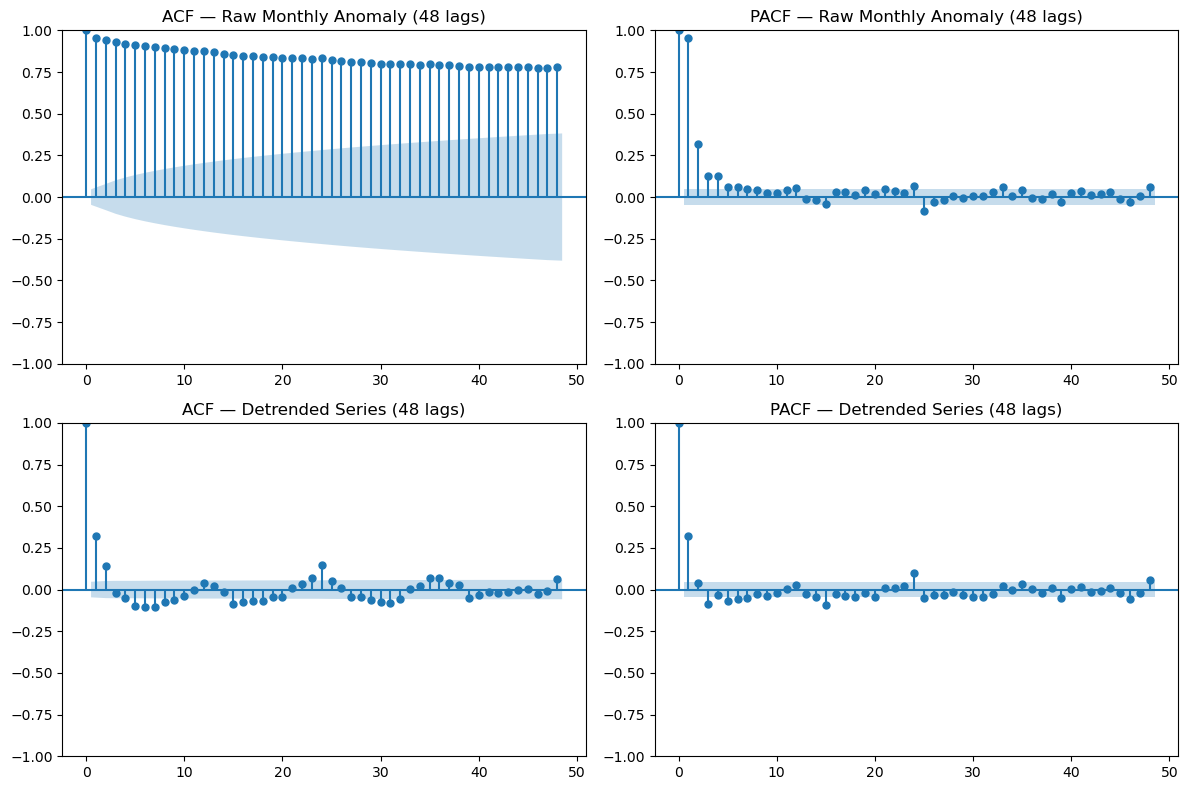

In [11]:
# Analyze autocorrelation using ACF plot. 
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the original series and the detrended series.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(ts_data.dropna(), lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF — Raw Monthly Anomaly (48 lags)")
plot_pacf(ts_data.dropna(), lags=48, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — Raw Monthly Anomaly (48 lags)")
 
detrended = stl_result.resid + stl_result.seasonal  # remove trend only, keep any seasonal + noise
plot_acf(detrended.dropna(), lags=48, ax=axes[1, 0])
axes[1, 0].set_title("ACF — Detrended Series (48 lags)")
plot_pacf(detrended.dropna(), lags=48, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — Detrended Series (48 lags)")
fig.tight_layout()
plt.show()

2. **Time Series Decomposition**

   - Decompose the time series into trend, seasonal, and residual components
   - Compare additive and multiplicative decomposition methods
   - Interpret your findings

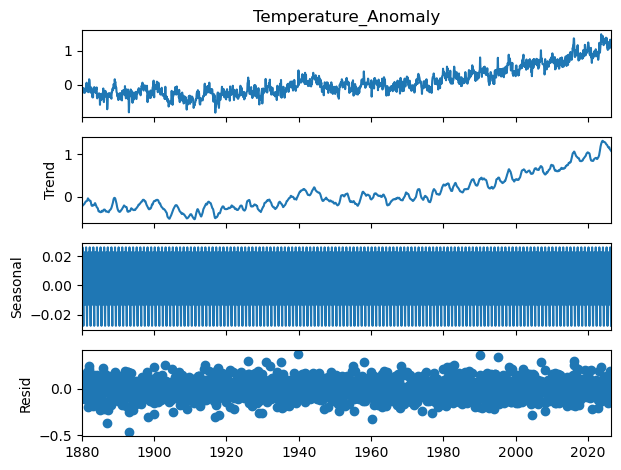

In [12]:
# Perform additive decomposition
decomposition = seasonal_decompose(ts_data, model='additive', period=12, extrapolate_trend="freq")

# Plot the decomposed components
fig = decomposition.plot()
plt.show()

Additive decomposition is the correct choice for this dataset, for two reasons:
1. the series contains negative values, which multiplicative decomposition can't handle without an arbitrary fix;
2. "temperature anomaly" is already a difference (from baseline), not a level -so an additive model matches the physical meaning of the data.

3. **Forecasting**

   - Split the data into training and testing sets using a temporal split
   - Implement and evaluate the following forecasting methods:
     - Naive forecasting (last value and seasonal naive)
     - ARIMA/SARIMA models
     - Exponential smoothing models
   - Use appropriate evaluation metrics (MAE, MAPE, sMAPE) to compare model performance

In [36]:
# split the data into train and test. At least the last 30 years will be the test set, and the prior years are the training set
y = ts_data
y_train, y_test = temporal_train_test_split(y, test_size=120)
y_train.shape

(1638,)

In [37]:
y_train = y_train.copy()
y_train.index = y_train.index.to_period('M')
y_test = y_test.copy()
y_test.index = y_test.index.to_period('M')

In [38]:
# Define the evaluation metrics

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
 
def mape(y_true, y_pred):
    # WARNING: undefined/explodes when y_true is near zero -- true here,
    # since anomalies cross zero. Reported for completeness, but see caveat below.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = np.abs(y_true) > 1e-6
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
 
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    nonzero = denom > 1e-6
    return np.mean(2 * np.abs(y_pred[nonzero] - y_true[nonzero]) / denom[nonzero]) * 100
 
results = {}
forecasts = {}
 
def evaluate(name, y_pred):
    y_pred = pd.Series(np.asarray(y_pred), index=y_test.index)
    results[name] = {
        "MAE": mae(y_test.values, y_pred.values),
        "MAPE": mape(y_test.values, y_pred.values),
        "sMAPE": smape(y_test.values, y_pred.values),
    }
    forecasts[name] = y_pred

In [39]:
# Initialize the naive forecaster
fh = np.arange(1, len(y_test) + 1)
forecaster = NaiveForecaster(strategy="last")
forecaster.fit(y_train)
naive_pred = forecaster.predict(fh=fh)
evaluate("Naive (last value)", naive_pred)

In [40]:
# Initialize the seasonal naive forecaster
forecaster = NaiveForecaster(strategy="last", sp=12)
forecaster.fit(y_train)
seasonal_naive_pred = forecaster.predict(fh=fh)
evaluate("Seasonal Naive (last value)", seasonal_naive_pred)

In [41]:
# Initialize ARIMA models
import pmdarima as pm
auto_model = pm.auto_arima(
    y_train, seasonal=True, m=12,
    d=1, D=0,  # d fixed from ADF result; D=0 since seasonality is negligible
    max_p=2, max_q=2, max_P=1, max_Q=1,
    stepwise=True, suppress_warnings=True, trace=False,
)
print("\nAuto-selected SARIMA order:", auto_model.order, auto_model.seasonal_order)


Auto-selected SARIMA order: (1, 1, 2) (0, 0, 1, 12)


In [42]:
h = 120
sarima_pred, sarima_ci = auto_model.predict(n_periods=h, return_conf_int=True)
evaluate("SARIMA (auto)", sarima_pred)

In [43]:
# Also fit a plain non-seasonal ARIMA for comparison, since our earlier analysis found seasonality negligible
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
arima_manual = SARIMAX(y_train, order=(1, 1, 1),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
arima_pred = arima_manual.get_forecast(steps=h).predicted_mean
evaluate("ARIMA(1,1,1) non-seasonal", arima_pred)

In [44]:
# Initialize Exponential smoothing models (Holt-Winters)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

#  trend='add' (captures the warming trend), damped to avoid over-extrapolating a straight line indefinitely;
#    seasonal='add' with period 12, included per instructions even though we expect its contribution to be small
hw_model = ExponentialSmoothing(
    y_train, trend="add", damped_trend=True,
    seasonal="add", seasonal_periods=12,
).fit()
hw_pred = hw_model.forecast(h)
evaluate("Holt-Winters (damped trend + seasonal)", hw_pred)
 
# Also a version without seasonal component, to isolate its effect
hw_model_nos = ExponentialSmoothing(
    y_train, trend="add", damped_trend=True, seasonal=None,
).fit()
hw_pred_nos = hw_model_nos.forecast(h)
evaluate("Holt-Winters (damped trend only)", hw_pred_nos)

In [48]:
# Results table

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("MAE")
print("\n=== Model comparison on held-out test set (last 10 years) ===")
print(results_df.round(4).to_string())


=== Model comparison on held-out test set (last 10 years) ===
                                           MAE     MAPE    sMAPE
Holt-Winters (damped trend + seasonal)  0.1538  14.4167  14.9819
Holt-Winters (damped trend only)        0.1562  14.4522  15.2252
ARIMA(1,1,1) non-seasonal               0.1587  15.5383  15.4893
SARIMA (auto)                           0.1764  15.4957  17.4272
Seasonal Naive (last value)             0.1978  20.1398  19.3530
Naive (last value)                      0.2171  19.0914  22.1491


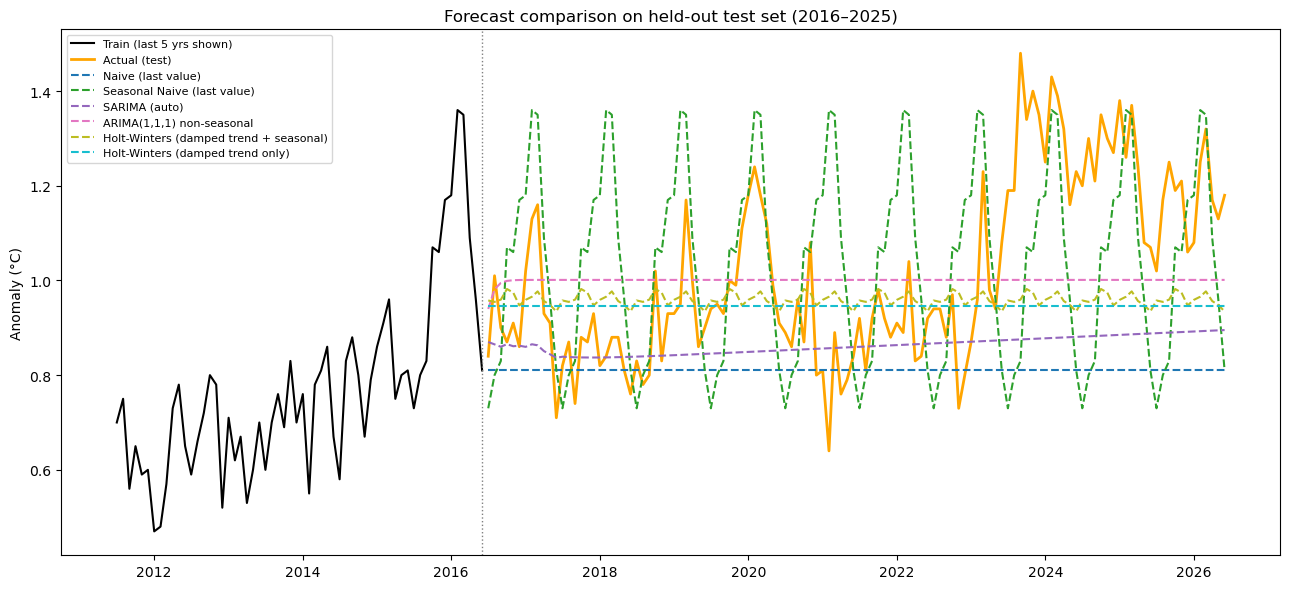

In [47]:
# Plot: actual vs each forecast

train_plot = y_train.copy()
train_plot.index = train_plot.index.to_timestamp()
test_plot = y_test.copy()
test_plot.index = test_plot.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train_plot.index[-60:], y_train.values[-60:], color="black", label="Train (last 5 yrs shown)")
ax.plot(test_plot.index, y_test.values, color="orange", linewidth=2, label="Actual (test)")
colors = plt.cm.tab10(np.linspace(0, 1, len(forecasts)))
for (name, fc), c in zip(forecasts.items(), colors):
    ax.plot(test_plot.index, fc.values, linestyle="--", color=c, label=name)
ax.axvline(train_plot.index[-1], color="gray", linestyle=":", linewidth=1)
ax.set_title("Forecast comparison on held-out test set (2016–2025)")
ax.set_ylabel("Anomaly (°C)")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()


4. **Model Selection and Interpretation**
   - Determine which model performs best for this dataset
   - Interpret the results and explain why certain models might work better than others
   - Generate forecasts for future periods

From the result table, Holt-Winters (damped trend + seasonal) showed the lowest MAE. But the gaps among Holt-Winters (seasonal or non-seasonal) and ARIMA is quite small. Possible reason for best Seasonal Holt-Winters could be that: more parameters = more flexibility to fit this specific test window. The seasonal model has extra parameters (γ + 12 seasonal indices) it can tune. Over a single 120-month test window, extra flexibility can accidentally align well with that particular decade's actual month-to-month wiggle, even if the "pattern" it's fitting isn't a stable, generalizable seasonal cycle — it's partly absorbing noise specific to 2016–2025.


In [52]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

final_model = ETSModel(
    ts_data,
    error="add",
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=12,
).fit(disp=False)

print(final_model.summary())
 
horizon = 120  # 10 years ahead: 2026-2035
future_index = pd.date_range(ts_data.index[-1] + pd.DateOffset(months=1), periods=horizon, freq="MS")
 
pred = final_model.get_prediction(start=future_index[0], end=future_index[-1])
pred_summary = pred.summary_frame(alpha=0.05)  # columns: mean, pi_lower, pi_upper (and mean_se)
pred_summary.index = future_index
 
fc_mean = pred_summary["mean"]
fc_lower = pred_summary["pi_lower"]
fc_upper = pred_summary["pi_upper"]

/home/liuyx/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                  ETS Results                                  
Dep. Variable:     Temperature_Anomaly   No. Observations:                 1758
Model:                       ETS(AAdA)   Log Likelihood                1399.728
Date:                 Fri, 17 Jul 2026   AIC                          -2761.456
Time:                         16:28:31   BIC                          -2657.490
Sample:                     01-01-1880   HQIC                         -2723.033
                          - 06-01-2026   Scale                            0.012
Covariance Type:                approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.4678      0.025     18.632      0.000       0.419       0.517
smoothing_trend      4.678e-05        nan        nan        nan         nan         nan
smoothin

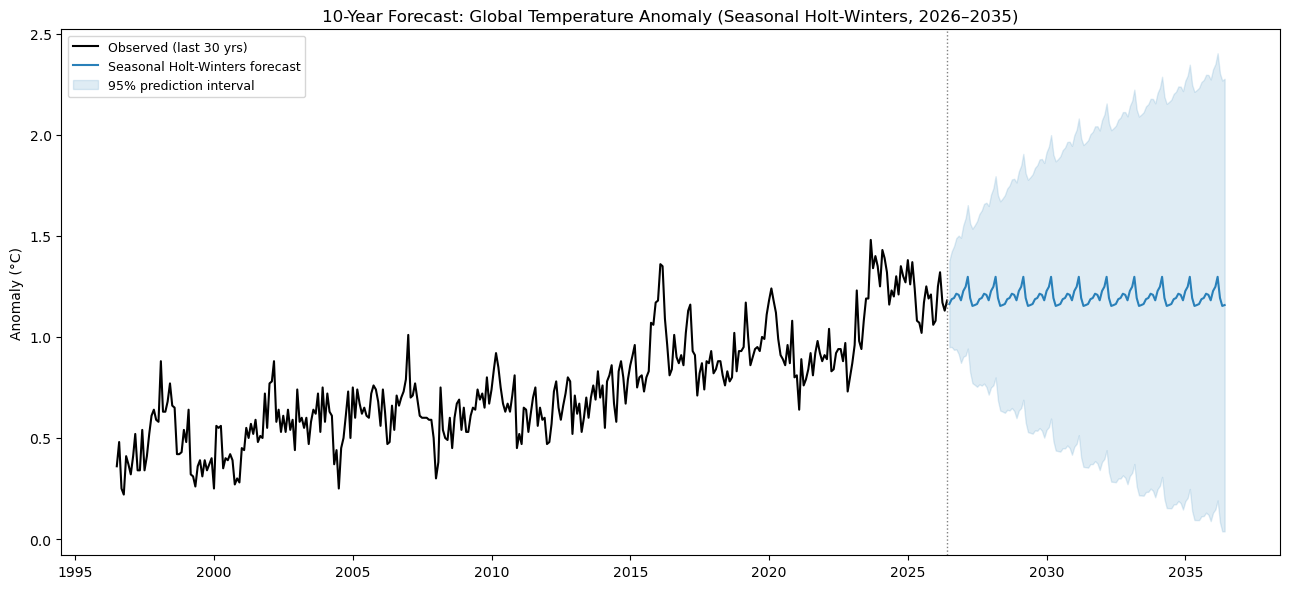


Forecast, first 12 months (2026):
2026-07-01    1.163
2026-08-01    1.187
2026-09-01    1.193
2026-10-01    1.214
2026-11-01    1.208
2026-12-01    1.181
2027-01-01    1.227
2027-02-01    1.248
2027-03-01    1.297
2027-04-01    1.193
2027-05-01    1.153
2027-06-01    1.158
Freq: MS, Name: mean, dtype: float64

Forecast, final 12 months (2035):
2035-07-01    1.163
2035-08-01    1.187
2035-09-01    1.193
2035-10-01    1.214
2035-11-01    1.208
2035-12-01    1.181
2036-01-01    1.227
2036-02-01    1.248
2036-03-01    1.297
2036-04-01    1.193
2036-05-01    1.153
2036-06-01    1.158
Freq: MS, Name: mean, dtype: float64

95% interval width, month 1 vs month 120:
Month 1  : 0.428
Month 120: 2.239

Projected seasonal swing in 2035 (max-min across the 12 months): 0.14412088460463113


In [55]:
# Plot: history + forecast + 95% prediction interval
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(ts_data.index[-360:], ts_data.values[-360:], color="black", label="Observed (last 30 yrs)")
ax.plot(fc_mean.index, fc_mean.values, color="#2980b9", label="Seasonal Holt-Winters forecast")
ax.fill_between(fc_mean.index, fc_lower, fc_upper, color="#2980b9", alpha=0.15, label="95% prediction interval")
ax.axvline(ts_data.index[-1], color="gray", linestyle=":", linewidth=1)
ax.set_title("10-Year Forecast: Global Temperature Anomaly (Seasonal Holt-Winters, 2026–2035)")
ax.set_ylabel("Anomaly (°C)")
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()
 
print("\nForecast, first 12 months (2026):")
print(fc_mean.head(12).round(3))
print("\nForecast, final 12 months (2035):")
print(fc_mean.tail(12).round(3))
 
print("\n95% interval width, month 1 vs month 120:")
print("Month 1  :", (fc_upper.iloc[0] - fc_lower.iloc[0]).round(3))
print("Month 120:", (fc_upper.iloc[-1] - fc_lower.iloc[-1]).round(3))
 
# Check whether the seasonal cycle is still visible in the projected
# forecast (it should be -- a small ~0.05 degC wiggle riding on the trend)
print("\nProjected seasonal swing in 2035 (max-min across the 12 months):",
      (fc_mean.tail(12).max() - fc_mean.tail(12).min()))